In [122]:
# ==============================================================================
# IMPORTS
# ==============================================================================

from openpiv import tools, pyprocess, validation, filters, scaling
import numpy as np
import tifffile as tif
import matplotlib.pyplot as plt
import napari
import pathlib
import scipy
from scipy.interpolate import griddata
from scipy.ndimage import map_coordinates
import pandas as pd

In [108]:
# CROP OFF CORNERS AND VISUALIZE IN NAPARI

first_dataset = tif.imread('/mnt/crunch/Clark/Fly_TFM/data/first/first_best.tif')
sitting_reference = first_dataset[350]
unstressed_reference = first_dataset[-1]

top_left_corner_sitting_reference = sitting_reference[0:830, 0:670]
bottom_left_corner_sitting_reference = sitting_reference[1630:2048, 0:450]
bottom_right_corner_sitting_reference = sitting_reference[1470:2048, 1410:2048]
top_right_corner_sitting_reference = sitting_reference[0:580, 1510:2048]

top_left_corner_unstressed_reference = unstressed_reference[0:830, 0:670]
bottom_left_corner_unstressed_reference = unstressed_reference[1630:2048, 0:450]
bottom_right_corner_unstressed_reference = unstressed_reference[1470:2048, 1410:2048]
top_right_corner_unstressed_reference = unstressed_reference[0:580, 1510:2048]

viewer = napari.Viewer()

# viewer.add_image(top_left_corner_sitting_reference, name='Top Left Corner', colormap='gray', contrast_limits=[0, 255])
viewer.add_image(bottom_left_corner_sitting_reference, name='Bottom Left Corner', colormap='gray', contrast_limits=[0, 255])
# viewer.add_image(bottom_right_corner_sitting_reference, name='Bottom Right Corner', colormap='gray', contrast_limits=[0, 255])
# viewer.add_image(top_right_corner_sitting_reference, name='Top Right Corner', colormap='gray', contrast_limits=[0, 255])
viewer.add_image(sitting_reference, name='Original Image', colormap='gray', contrast_limits=[0, 255])

# viewer.add_image(top_left_corner_unstressed_reference, name='Top Left Corner', colormap='gray', contrast_limits=[0, 255])
viewer.add_image(bottom_left_corner_unstressed_reference, name='Bottom Left Corner', colormap='gray', contrast_limits=[0, 255])
# viewer.add_image(bottom_right_corner_unstressed_reference, name='Bottom Right Corner', colormap='gray', contrast_limits=[0, 255])
# viewer.add_image(top_right_corner_unstressed_reference, name='Top Right Corner', colormap='gray', contrast_limits=[0, 255])
viewer.add_image(unstressed_reference, name='Original Image', colormap='gray', contrast_limits=[0, 255])

napari.run()

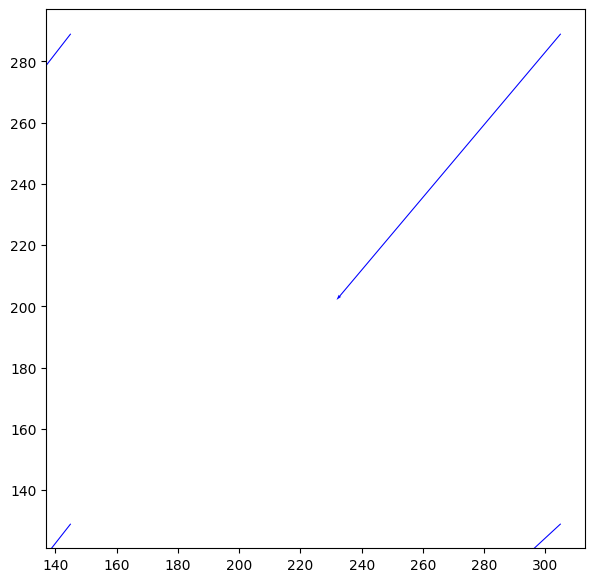

(<Figure size 700x700 with 1 Axes>, <Axes: >)

In [130]:
# STEP 1: RUN COARSE FIRST PASS

# ------------------------------------------------------------------------------

# SECTION PIV parameters (window_size - overlap = step_size)

# window_size = 128
# search_size = 135
# overlap = 64

window_size = 150
search_size = 160
overlap = 0

# !SECTION

# ------------------------------------------------------------------------------

# SECTION Run the actual PIV

u_0, v_0, sig2noise = pyprocess.extended_search_area_piv(
    bottom_left_corner_sitting_reference.astype(np.int32), # first image
    bottom_left_corner_unstressed_reference.astype(np.int32), # second image
    window_size=window_size,
    overlap=overlap,
    dt=1,
    search_area_size=search_size,
    sig2noise_method='peak2peak'
)

# !SECTION

# ------------------------------------------------------------------------------

# SECTION Postprocessing

# Get mask of vectors, 0 = above threshold, 1 = below threshold
invalid_mask = validation.sig2noise_val(
    sig2noise,
    threshold=1.3
)

# Replace outliers with local mean
u_0_filtered, v_0_filtered = filters.replace_outliers(
    u_0,
    v_0,
    invalid_mask,
    method='localmean',
    max_iter=3,
    kernel_size=2
)

# Get x y coords of center of interrogation windows
x_0, y_0 = pyprocess.get_coordinates(
    image_size=bottom_left_corner_sitting_reference.shape,
    search_area_size=search_size,
    overlap=overlap
)

# Flip coords so that origin is bottom left corner
x_0_flipped, y_0_flipped, u_0_flipped, v_0_flipped = tools.transform_coordinates(
    x_0,
    y_0,
    u_0_filtered,
    v_0_filtered
)

# Save
tools.save('first_pass_results.txt', x_0_flipped, y_0_flipped, u_0_flipped, v_0_flipped, invalid_mask)

# !SECTION

# --- Visualize ---
fig, ax = plt.subplots(figsize=(7, 7))
tools.display_vector_field(
    pathlib.Path('first_pass_results.txt'),
    ax=ax,
    scaling_factor=1,
    scale=10,
    width=0.002,
)

In [128]:
# STEP 2: WARP IMAGE BASED ON FIRST PASS RESULTS

# ------------------------------------------------------------------------------

ref1 = bottom_left_corner_unstressed_reference
ref2 = bottom_left_corner_sitting_reference

H, W = ref1.shape
grid_x, grid_y = np.meshgrid(np.arange(W), np.arange(H))

points = np.column_stack([x_0_flipped.ravel(), y_0_flipped.ravel()])
u_dense = scipy.interpolate.griddata(points, u_0_flipped.ravel(), (grid_x, grid_y), method='cubic')
v_dense = scipy.interpolate.griddata(points, v_0_flipped.ravel(), (grid_x, grid_y), method='cubic')

# # nan fill for anything outside convex hull of your 4 points
# u_dense = np.nan_to_num(u_dense)
# v_dense = np.nan_to_num(v_dense)

# warp ref2 toward ref1
coords_x = grid_x - u_dense
coords_y = grid_y + v_dense
warped_ref2 = scipy.ndimage.map_coordinates(ref2, [coords_y, coords_x], order=1)

# visualize: does warped_ref2 look more like ref1 than raw ref2 did?
# fig, axs = plt.subplots(1, 3, figsize=(15,5))
# axs[0].imshow(ref1 - ref2, cmap='gray'); axs[0].set_title('ref1 - ref2 (raw)')
# axs[1].imshow(ref1 - warped_ref2, cmap='gray'); axs[1].set_title('ref1 - warped_ref2')
# axs[2].imshow(warped_ref2, cmap='gray'); axs[2].set_title('warped_ref2')
# plt.show()

viewer = napari.Viewer()
viewer.add_image(ref1, name='Reference 1', colormap='gray', contrast_limits=[0, 255])
viewer.add_image(ref2, name='Reference 2', colormap='gray', contrast_limits=[0, 255])
viewer.add_image(warped_ref2, name='Warped Reference 2', colormap='gray', contrast_limits=[0, 255])
napari.run()